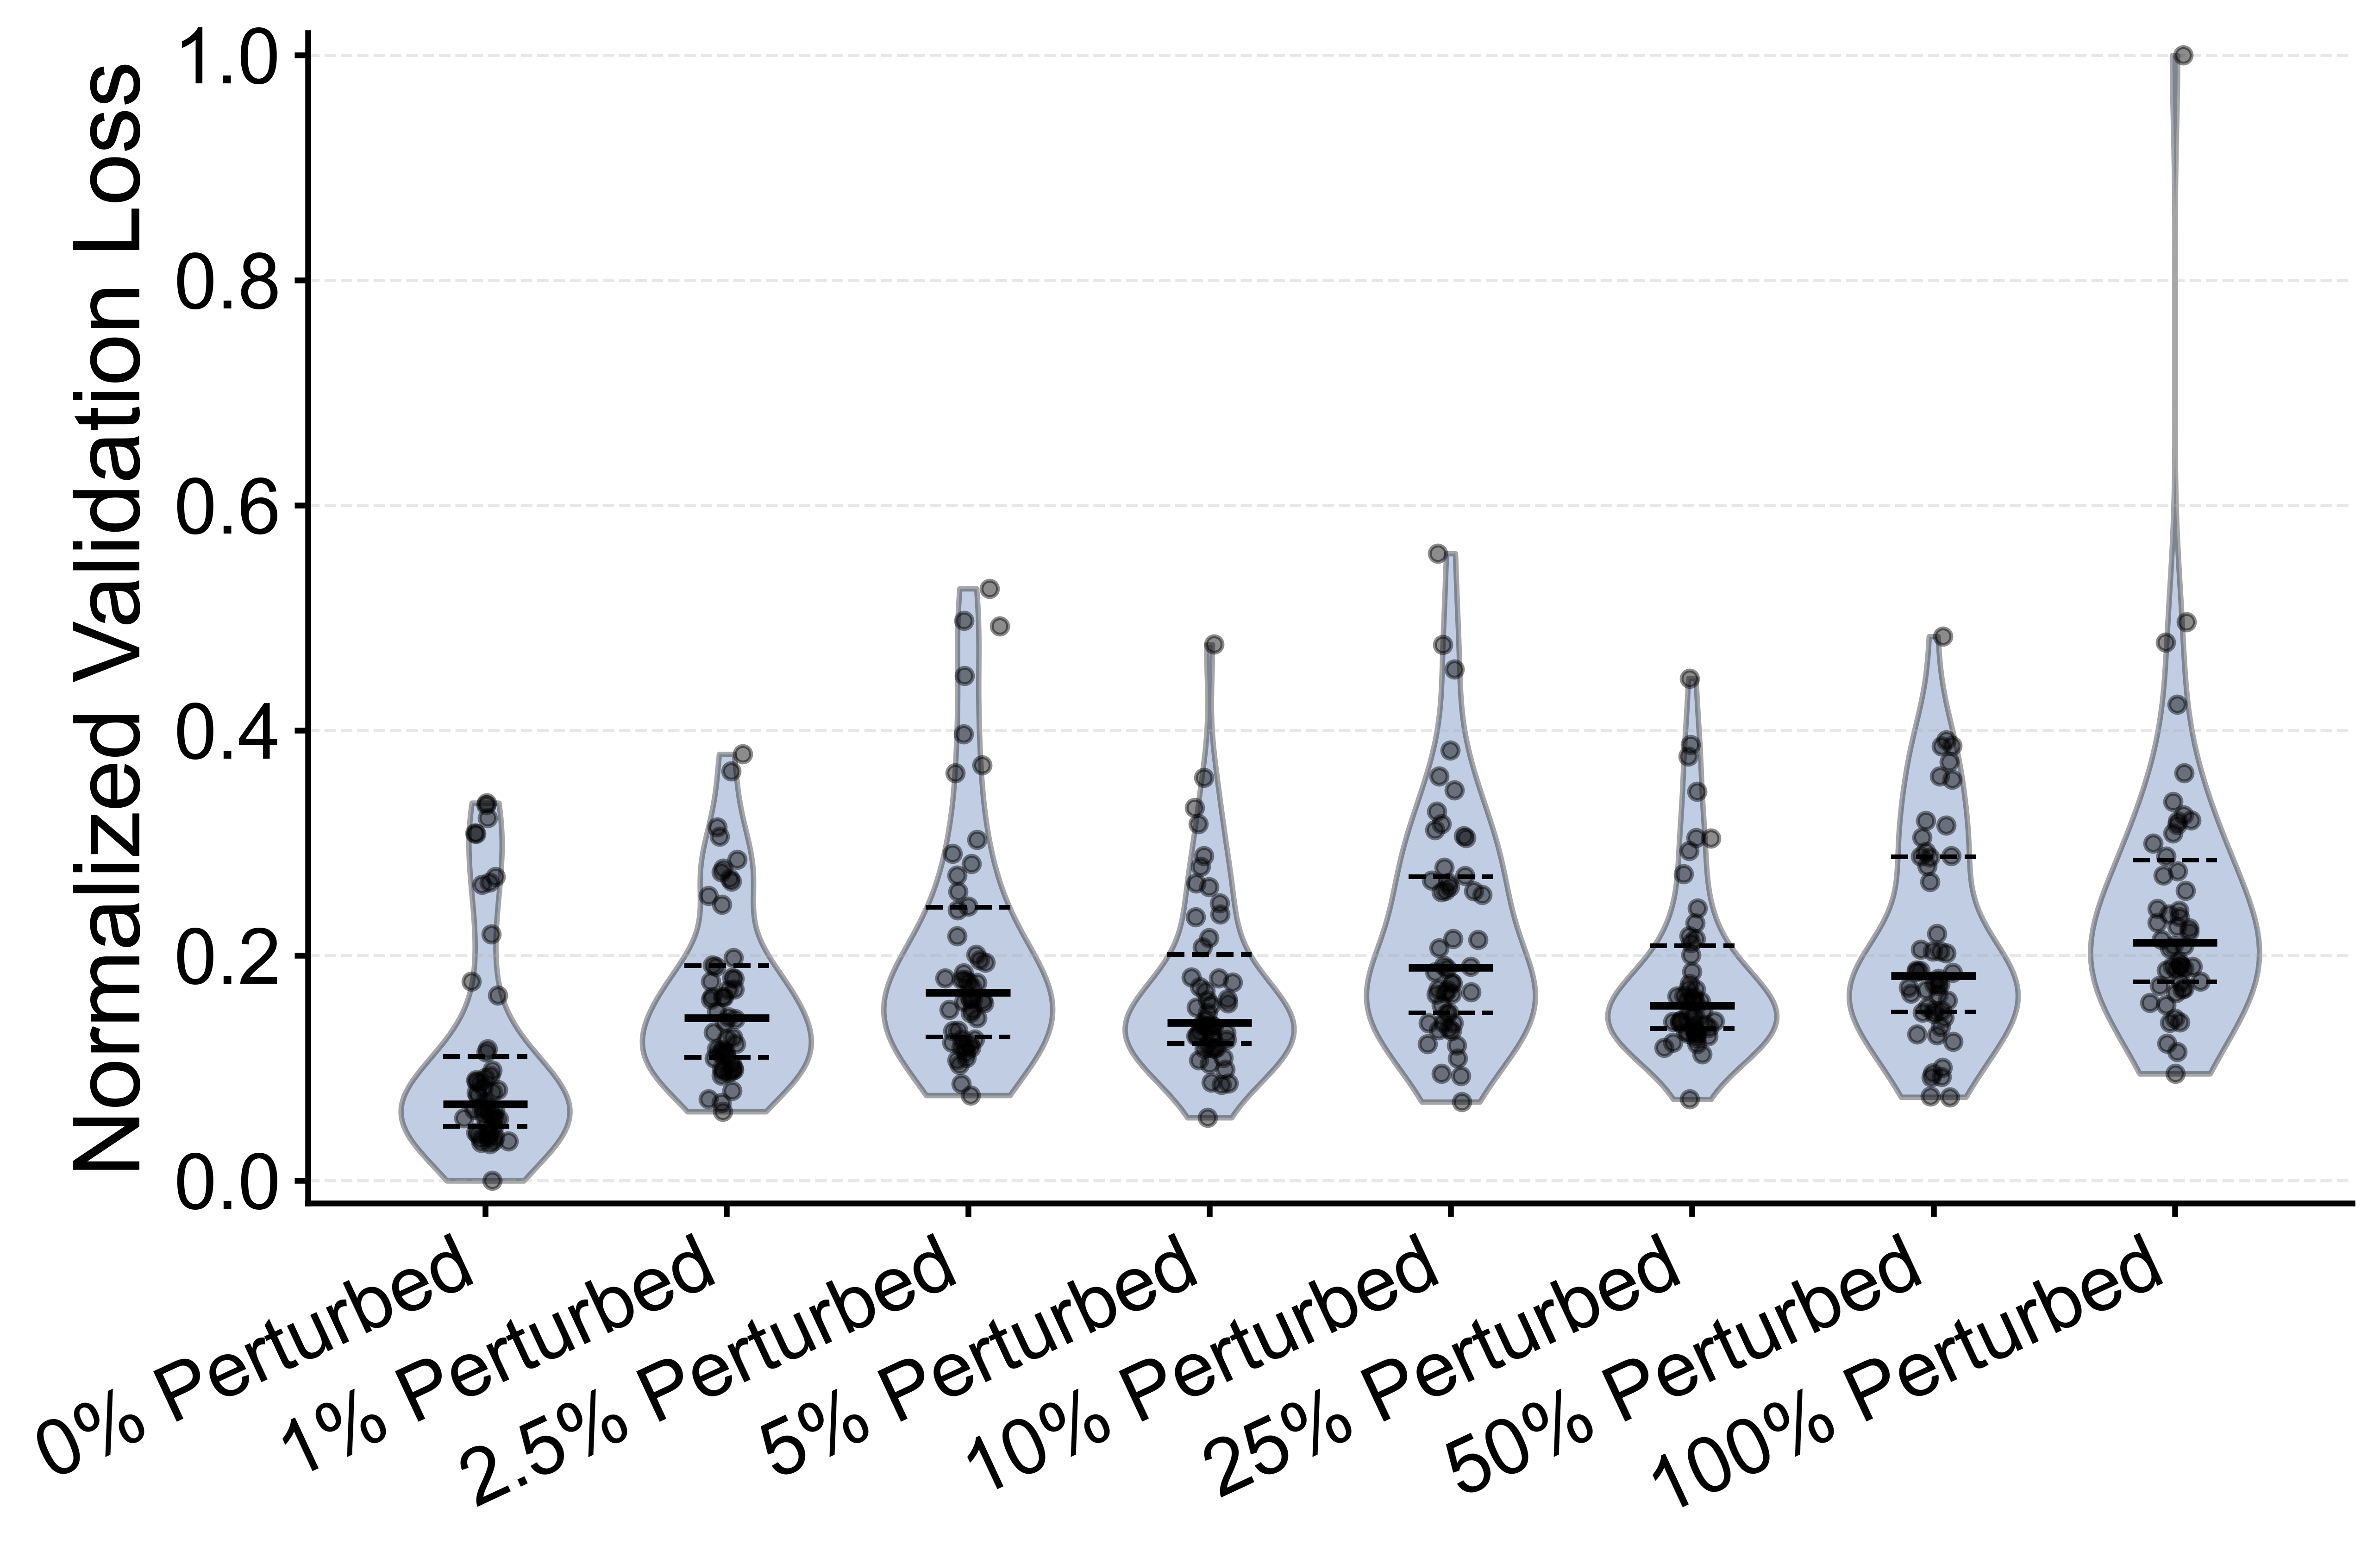

In [28]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Validation_loss_CNN2_MLP_GNN.txt",
    "Validation_loss_CNN2_MLP_GNN_001.txt",
    "Validation_loss_CNN2_MLP_GNN_0025.txt",
    "Validation_loss_CNN2_MLP_GNN_005.txt",
    "Validation_loss_CNN2_MLP_GNN_010.txt",
    "Validation_loss_CNN2_MLP_GNN_025.txt",
    "Validation_loss_CNN2_MLP_GNN_050.txt",
    "Validation_loss_CNN2_MLP_GNN_100.txt"
]

labels = [
    "0% Perturbed",
    "1% Perturbed",
    "2.5% Perturbed",
    "5% Perturbed",
    "10% Perturbed",
    "25% Perturbed",
    "50% Perturbed",
    "100% Perturbed"
]

groups = []
for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# Normalize using global min and max across all five groups
all_values = np.concatenate(groups)
vmin = all_values.min()
vmax = all_values.max()

groups_norm = [(g - vmin) / (vmax - vmin) for g in groups]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

fig, ax = plt.subplots(figsize=(9, 6), dpi=600)

parts = ax.violinplot(
    groups_norm,
    positions=np.arange(1, len(groups_norm) + 1),
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    quantiles=[[0.25, 0.75]] * len(groups_norm)
)

for body in parts["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_edgecolor("black")
    body.set_alpha(0.35)
    body.set_linewidth(1.4)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

parts["cquantiles"].set_color("black")
parts["cquantiles"].set_linestyle("--")
parts["cquantiles"].set_linewidth(1.2)

rng = np.random.default_rng(42)

for i, data in enumerate(groups_norm, start=1):
    x = rng.normal(i, 0.045, len(data))
    ax.scatter(
        x,
        data,
        s=18,
        color="black",
        alpha=0.45,
        zorder=3
    )

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=25, ha="right")

ax.set_ylabel("Normalized Validation Loss", fontsize=24)
ax.set_ylim(-0.02, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("Validation_loss_violin_plot.png", dpi=600, bbox_inches="tight")
plt.show()

Median values:
  0.0%: median = 0.0679, 25th = 0.0483, 75th = 0.1103
  1.0%: median = 0.1447, 25th = 0.1097, 75th = 0.1912
  2.5%: median = 0.1671, 25th = 0.1276, 75th = 0.2428
  5.0%: median = 0.1404, 25th = 0.1218, 75th = 0.2010
 10.0%: median = 0.1895, 25th = 0.1490, 75th = 0.2700
 25.0%: median = 0.1555, 25th = 0.1349, 75th = 0.2086
 50.0%: median = 0.1822, 25th = 0.1499, 75th = 0.2880
100.0%: median = 0.2116, 25th = 0.1766, 75th = 0.2849

Slope     = 0.000800
Intercept = 0.138000
R²        = 0.4182


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_30493/1632340289.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


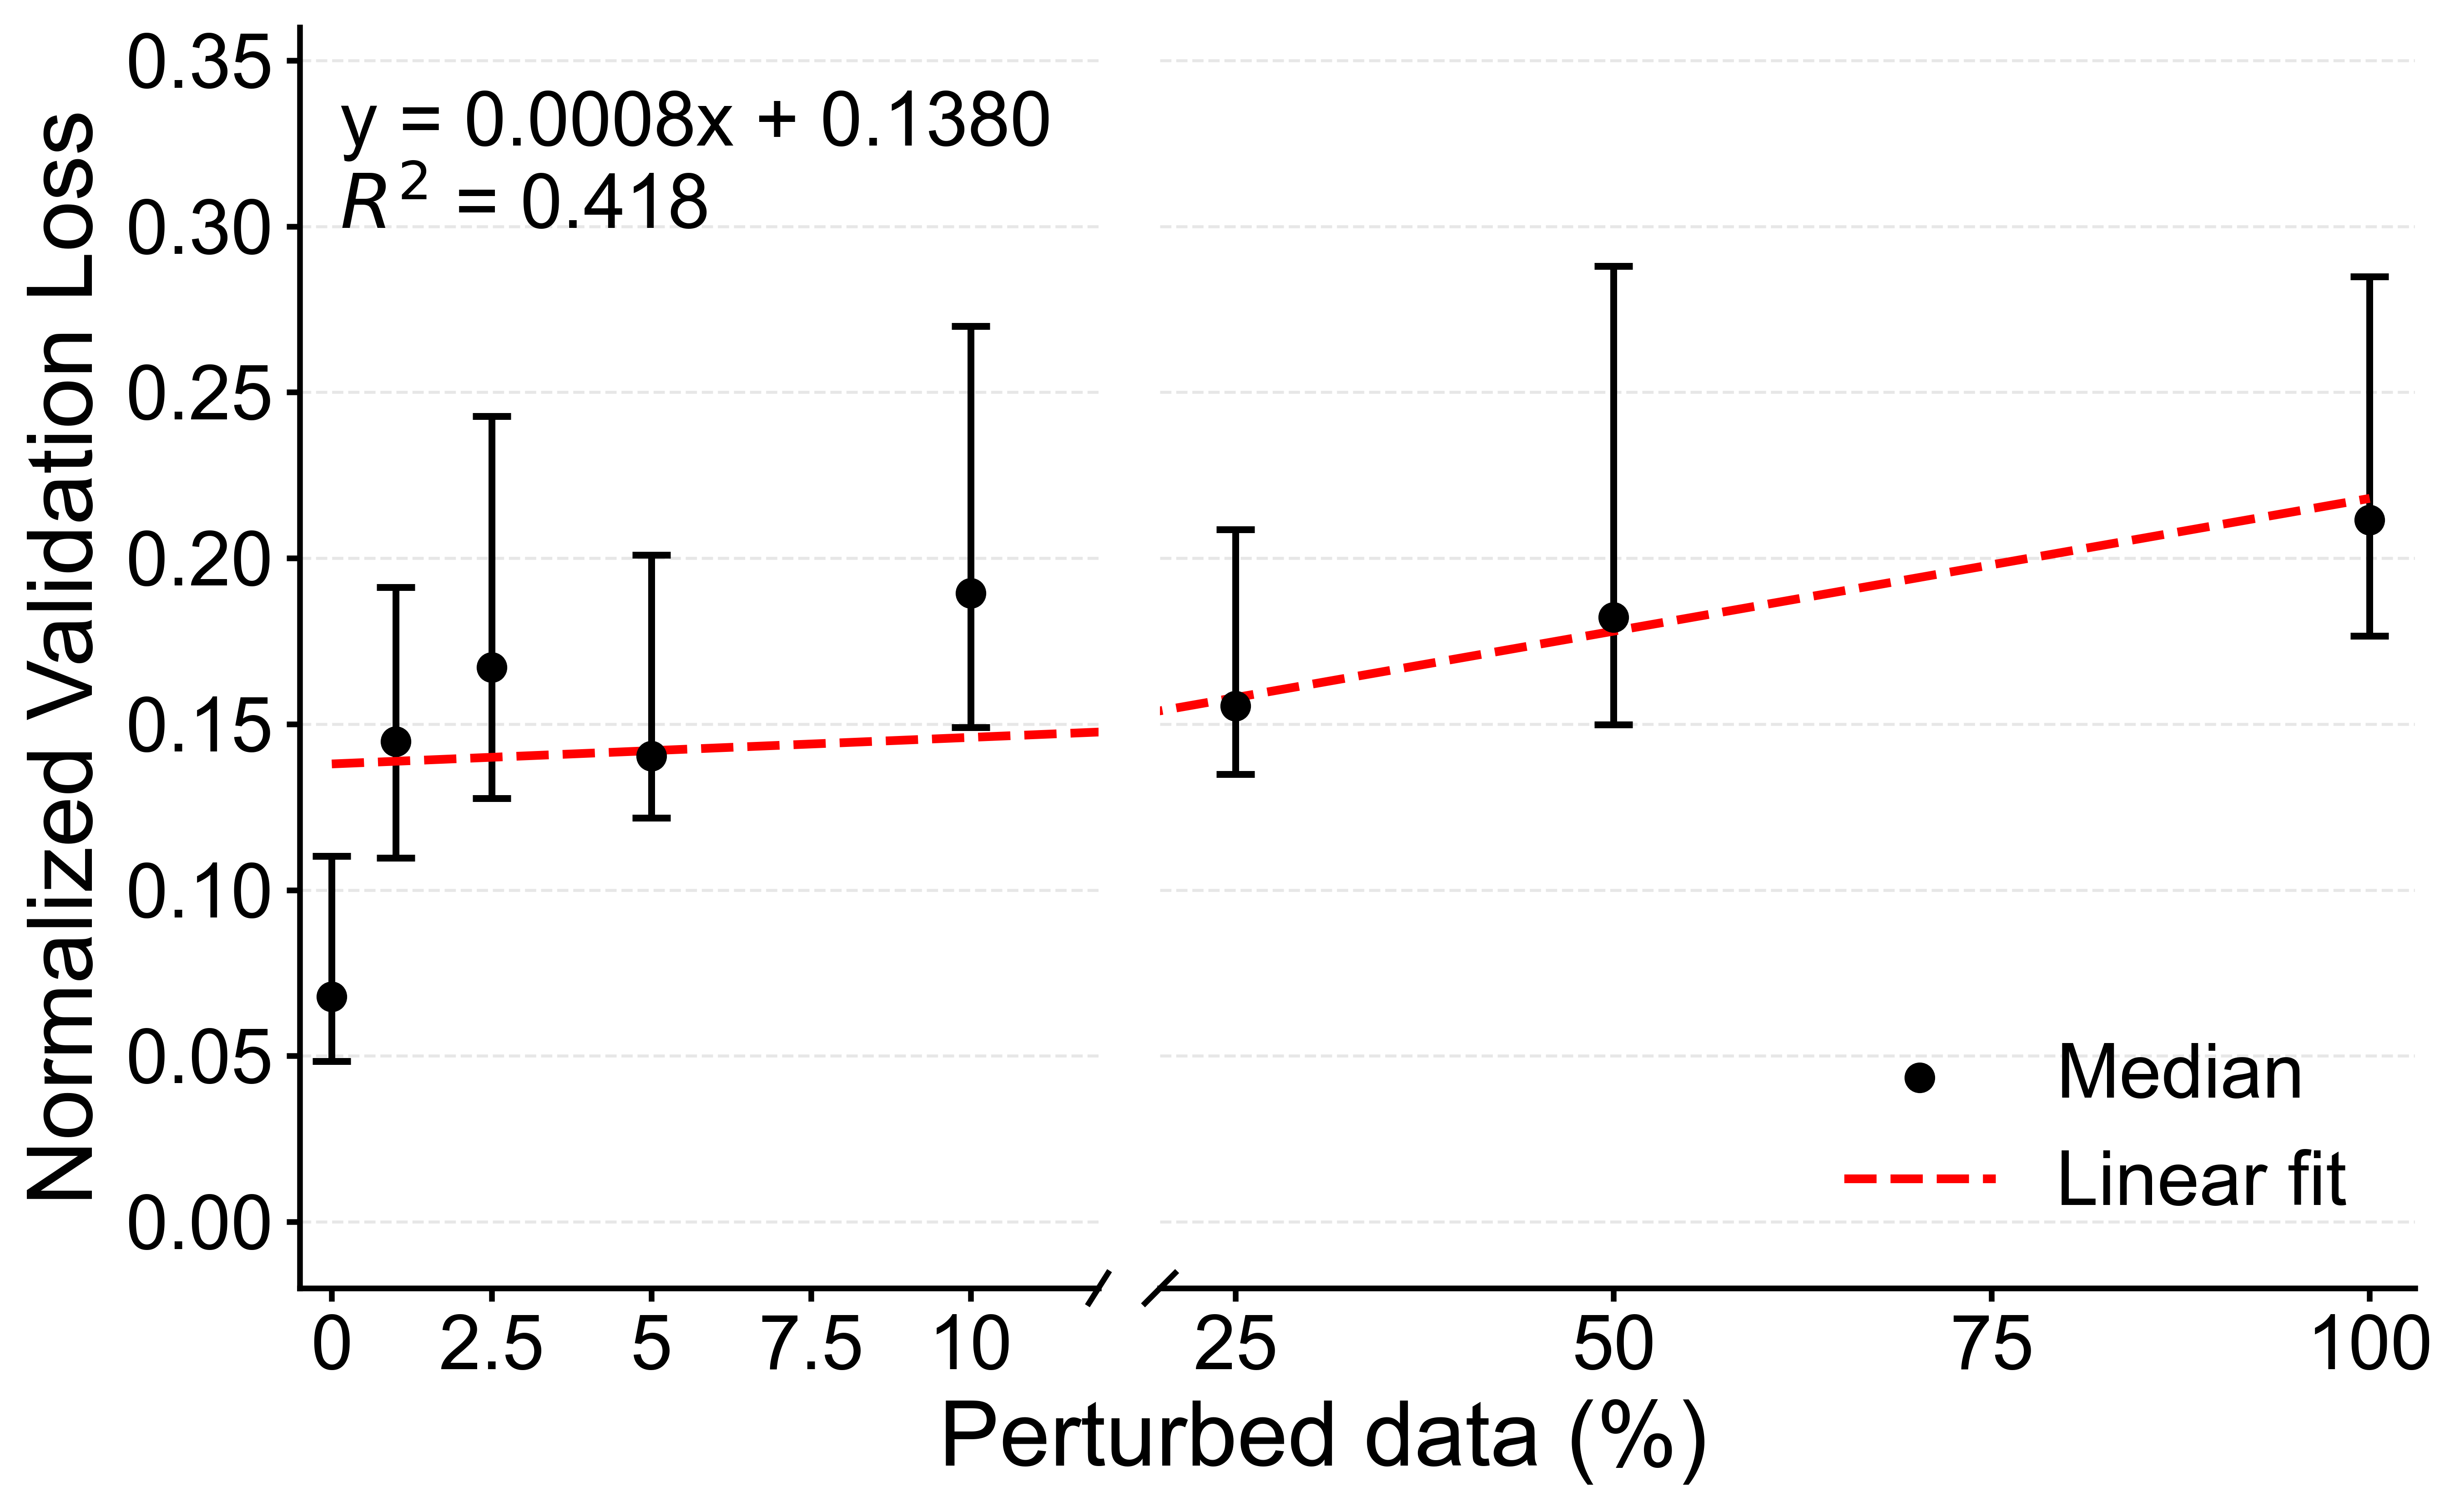

In [29]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Validation_loss_CNN2_MLP_GNN.txt",
    "Validation_loss_CNN2_MLP_GNN_001.txt",
    "Validation_loss_CNN2_MLP_GNN_0025.txt",
    "Validation_loss_CNN2_MLP_GNN_005.txt",
    "Validation_loss_CNN2_MLP_GNN_010.txt",
    "Validation_loss_CNN2_MLP_GNN_025.txt",
    "Validation_loss_CNN2_MLP_GNN_050.txt",
    "Validation_loss_CNN2_MLP_GNN_100.txt"
]

# Actual perturbation percentages
perturbation = np.array([0, 1, 2.5, 5, 10, 25, 50, 100])

# ============================================================
# Load data
# ============================================================

groups = []

for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# ============================================================
# Global normalization
# ============================================================

all_values = np.concatenate(groups)

vmin = all_values.min()
vmax = all_values.max()

groups_norm = [
    (g - vmin) / (vmax - vmin)
    for g in groups
]

# ============================================================
# Calculate median, 25th percentile, and 75th percentile
# ============================================================

medians = np.array([
    np.median(g)
    for g in groups_norm
])

q25 = np.array([
    np.percentile(g, 25)
    for g in groups_norm
])

q75 = np.array([
    np.percentile(g, 75)
    for g in groups_norm
])

# Error-bar lengths
lower_error = medians - q25
upper_error = q75 - medians

yerr = np.vstack([
    lower_error,
    upper_error
])

# ============================================================
# Linear regression of median values
# ============================================================

slope, intercept = np.polyfit(
    perturbation,
    medians,
    1
)

# Generate many x-values so regression line is smooth
x_fit = np.linspace(
    perturbation.min(),
    perturbation.max(),
    500
)

y_fit = slope * x_fit + intercept

# Predicted values at actual perturbation percentages
predicted = slope * perturbation + intercept

# R²
ss_res = np.sum(
    (medians - predicted) ** 2
)

ss_tot = np.sum(
    (medians - np.mean(medians)) ** 2
)

r_squared = 1 - ss_res / ss_tot

print("Median values:")

for x, median, lower, upper in zip(
    perturbation,
    medians,
    q25,
    q75
):
    print(
        f"{x:5.1f}%: "
        f"median = {median:.4f}, "
        f"25th = {lower:.4f}, "
        f"75th = {upper:.4f}"
    )

print()
print(f"Slope     = {slope:.6f}")
print(f"Intercept = {intercept:.6f}")
print(f"R²        = {r_squared:.4f}")


# ============================================================
# Plot settings
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

# Two x-axis regions:
# left = 0–12%
# right = 20–103%
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 6),
    dpi=600,
    gridspec_kw={
        "width_ratios": [1.4, 2.2],
        "wspace": 0.06
    }
)

# ============================================================
# Function for plotting the same data on both axes
# ============================================================

def plot_data(ax):

    # Median points
    ax.scatter(
        perturbation,
        medians,
        color="black",
        s=50,
        zorder=3,
        label="Median"
    )

    # 25th–75th percentile bars
    ax.errorbar(
        perturbation,
        medians,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1.8,
        capsize=5,
        capthick=1.8,
        zorder=2
    )

    # Linear regression line
    ax.plot(
        x_fit,
        y_fit,
        color="red",
        linewidth=2.3,
        linestyle="--",
        label="Linear fit"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)


# Plot on both axes
plot_data(ax1)
plot_data(ax2)

# ============================================================
# Define the two continuous x-axis regions
# ============================================================

ax1.set_xlim(-0.5, 12)
ax2.set_xlim(20, 103)

# Left region: low perturbation levels
ax1.set_xticks([
    0,
    2.5,
    5,
    7.5,
    10
])

ax1.set_xticklabels([
    "0",
    "2.5",
    "5",
    "7.5",
    "10"
])

# Right region
ax2.set_xticks([
    25,
    50,
    75,
    100
])

ax2.set_xticklabels([
    "25",
    "50",
    "75",
    "100"
])

# ============================================================
# Y-axis
# ============================================================

ax1.set_ylim(-0.02, 0.36)

ax1.set_ylabel(
    "Normalized Validation Loss",
    fontsize=24
)

# Common X-axis label
fig.supxlabel(
    "Perturbed data (%)",
    fontsize=24,
    y=-0.01
)

# ============================================================
# Remove internal spines
# ============================================================

ax1.spines["right"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# ============================================================
# Add broken-axis diagonal marks
# ============================================================

d = 0.012

kwargs = dict(
    transform=ax1.transAxes,
    color="black",
    clip_on=False,
    linewidth=1.5
)

ax1.plot(
    (1 - d, 1 + d),
    (-d, +d),
    **kwargs
)

kwargs.update(
    transform=ax2.transAxes
)

ax2.plot(
    (-d, +d),
    (-d, +d),
    **kwargs
)

# ============================================================
# Regression equation and R²
# ============================================================

equation_text = (
    f"y = {slope:.4f}x + {intercept:.4f}\n"
    f"$R^2$ = {r_squared:.3f}"
)

ax1.text(
    0.05,
    0.95,
    equation_text,
    transform=ax1.transAxes,
    fontsize=20,
    verticalalignment="top",
    horizontalalignment="left"
)

# ============================================================
# Legend
# ============================================================

ax2.legend(
    loc="lower right",
    frameon=False,
    fontsize=20
)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    "Validation_loss_median_linear_fit_broken_axis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

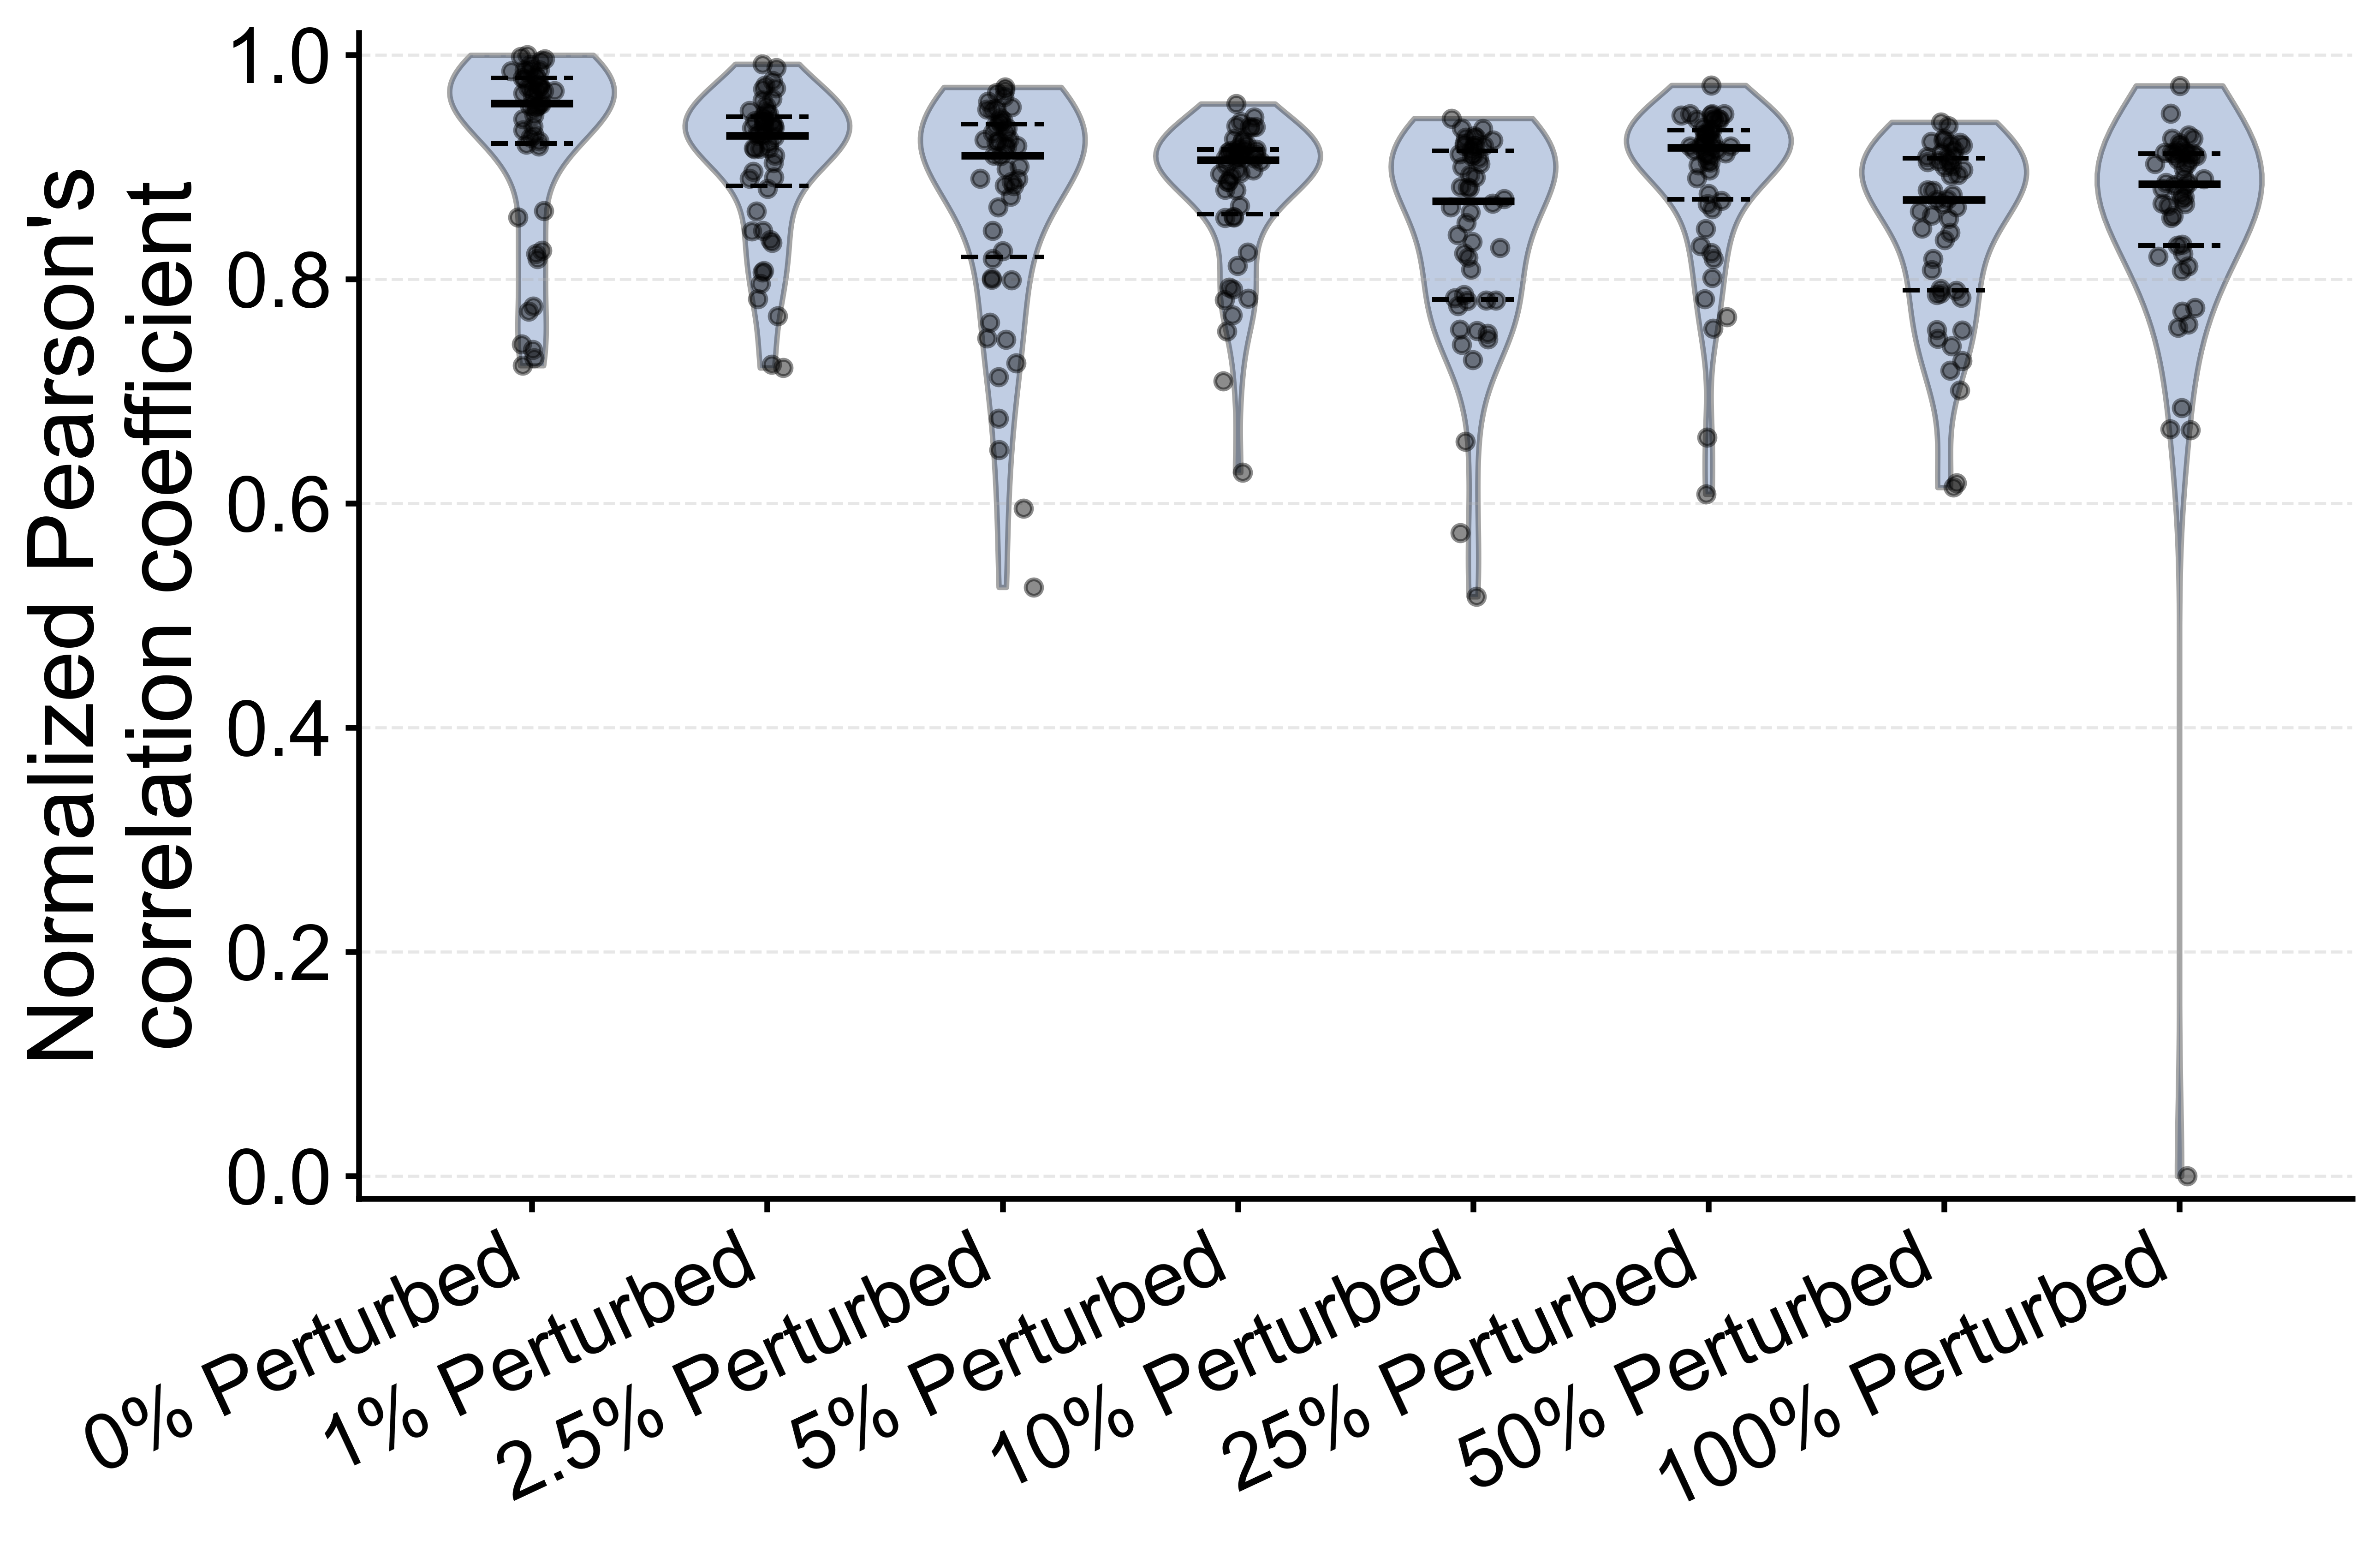

In [30]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Pearson_CNN2_MLP_GNN.txt",
    "Pearson_CNN2_MLP_GNN_001.txt",
    "Pearson_CNN2_MLP_GNN_0025.txt",
    "Pearson_CNN2_MLP_GNN_005.txt",
    "Pearson_CNN2_MLP_GNN_010.txt",
    "Pearson_CNN2_MLP_GNN_025.txt",
    "Pearson_CNN2_MLP_GNN_050.txt",
    "Pearson_CNN2_MLP_GNN_100.txt"
]

labels = [
    "0% Perturbed",
    "1% Perturbed",
    "2.5% Perturbed",
    "5% Perturbed",
    "10% Perturbed",
    "25% Perturbed",
    "50% Perturbed",
    "100% Perturbed"
]

groups = []
for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# Normalize using global min and max across all five groups
all_values = np.concatenate(groups)
vmin = all_values.min()
vmax = all_values.max()

groups_norm = [(g - vmin) / (vmax - vmin) for g in groups]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

fig, ax = plt.subplots(figsize=(9, 6), dpi=600)

parts = ax.violinplot(
    groups_norm,
    positions=np.arange(1, len(groups_norm) + 1),
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    quantiles=[[0.25, 0.75]] * len(groups_norm)
)

for body in parts["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_edgecolor("black")
    body.set_alpha(0.35)
    body.set_linewidth(1.4)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

parts["cquantiles"].set_color("black")
parts["cquantiles"].set_linestyle("--")
parts["cquantiles"].set_linewidth(1.2)

rng = np.random.default_rng(42)

for i, data in enumerate(groups_norm, start=1):
    x = rng.normal(i, 0.045, len(data))
    ax.scatter(
        x,
        data,
        s=18,
        color="black",
        alpha=0.45,
        zorder=3
    )

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=25, ha="right")

ax.set_ylabel("Normalized Pearson's\ncorrelation coefficient", fontsize=24)
ax.set_ylim(-0.02, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("Pearson_violin_plot.png", dpi=600, bbox_inches="tight")
plt.show()

Median values:
  0.0%: median = 0.9569, 25th = 0.9209, 75th = 0.9794
  1.0%: median = 0.9282, 25th = 0.8831, 75th = 0.9448
  2.5%: median = 0.9102, 25th = 0.8200, 75th = 0.9385
  5.0%: median = 0.9063, 25th = 0.8581, 75th = 0.9158
 10.0%: median = 0.8697, 25th = 0.7819, 75th = 0.9145
 25.0%: median = 0.9173, 25th = 0.8715, 75th = 0.9332
 50.0%: median = 0.8711, 25th = 0.7902, 75th = 0.9080
100.0%: median = 0.8851, 25th = 0.8303, 75th = 0.9120

Slope     = -0.000444
Intercept = 0.916341
R²        = 0.2724


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_30493/779757842.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


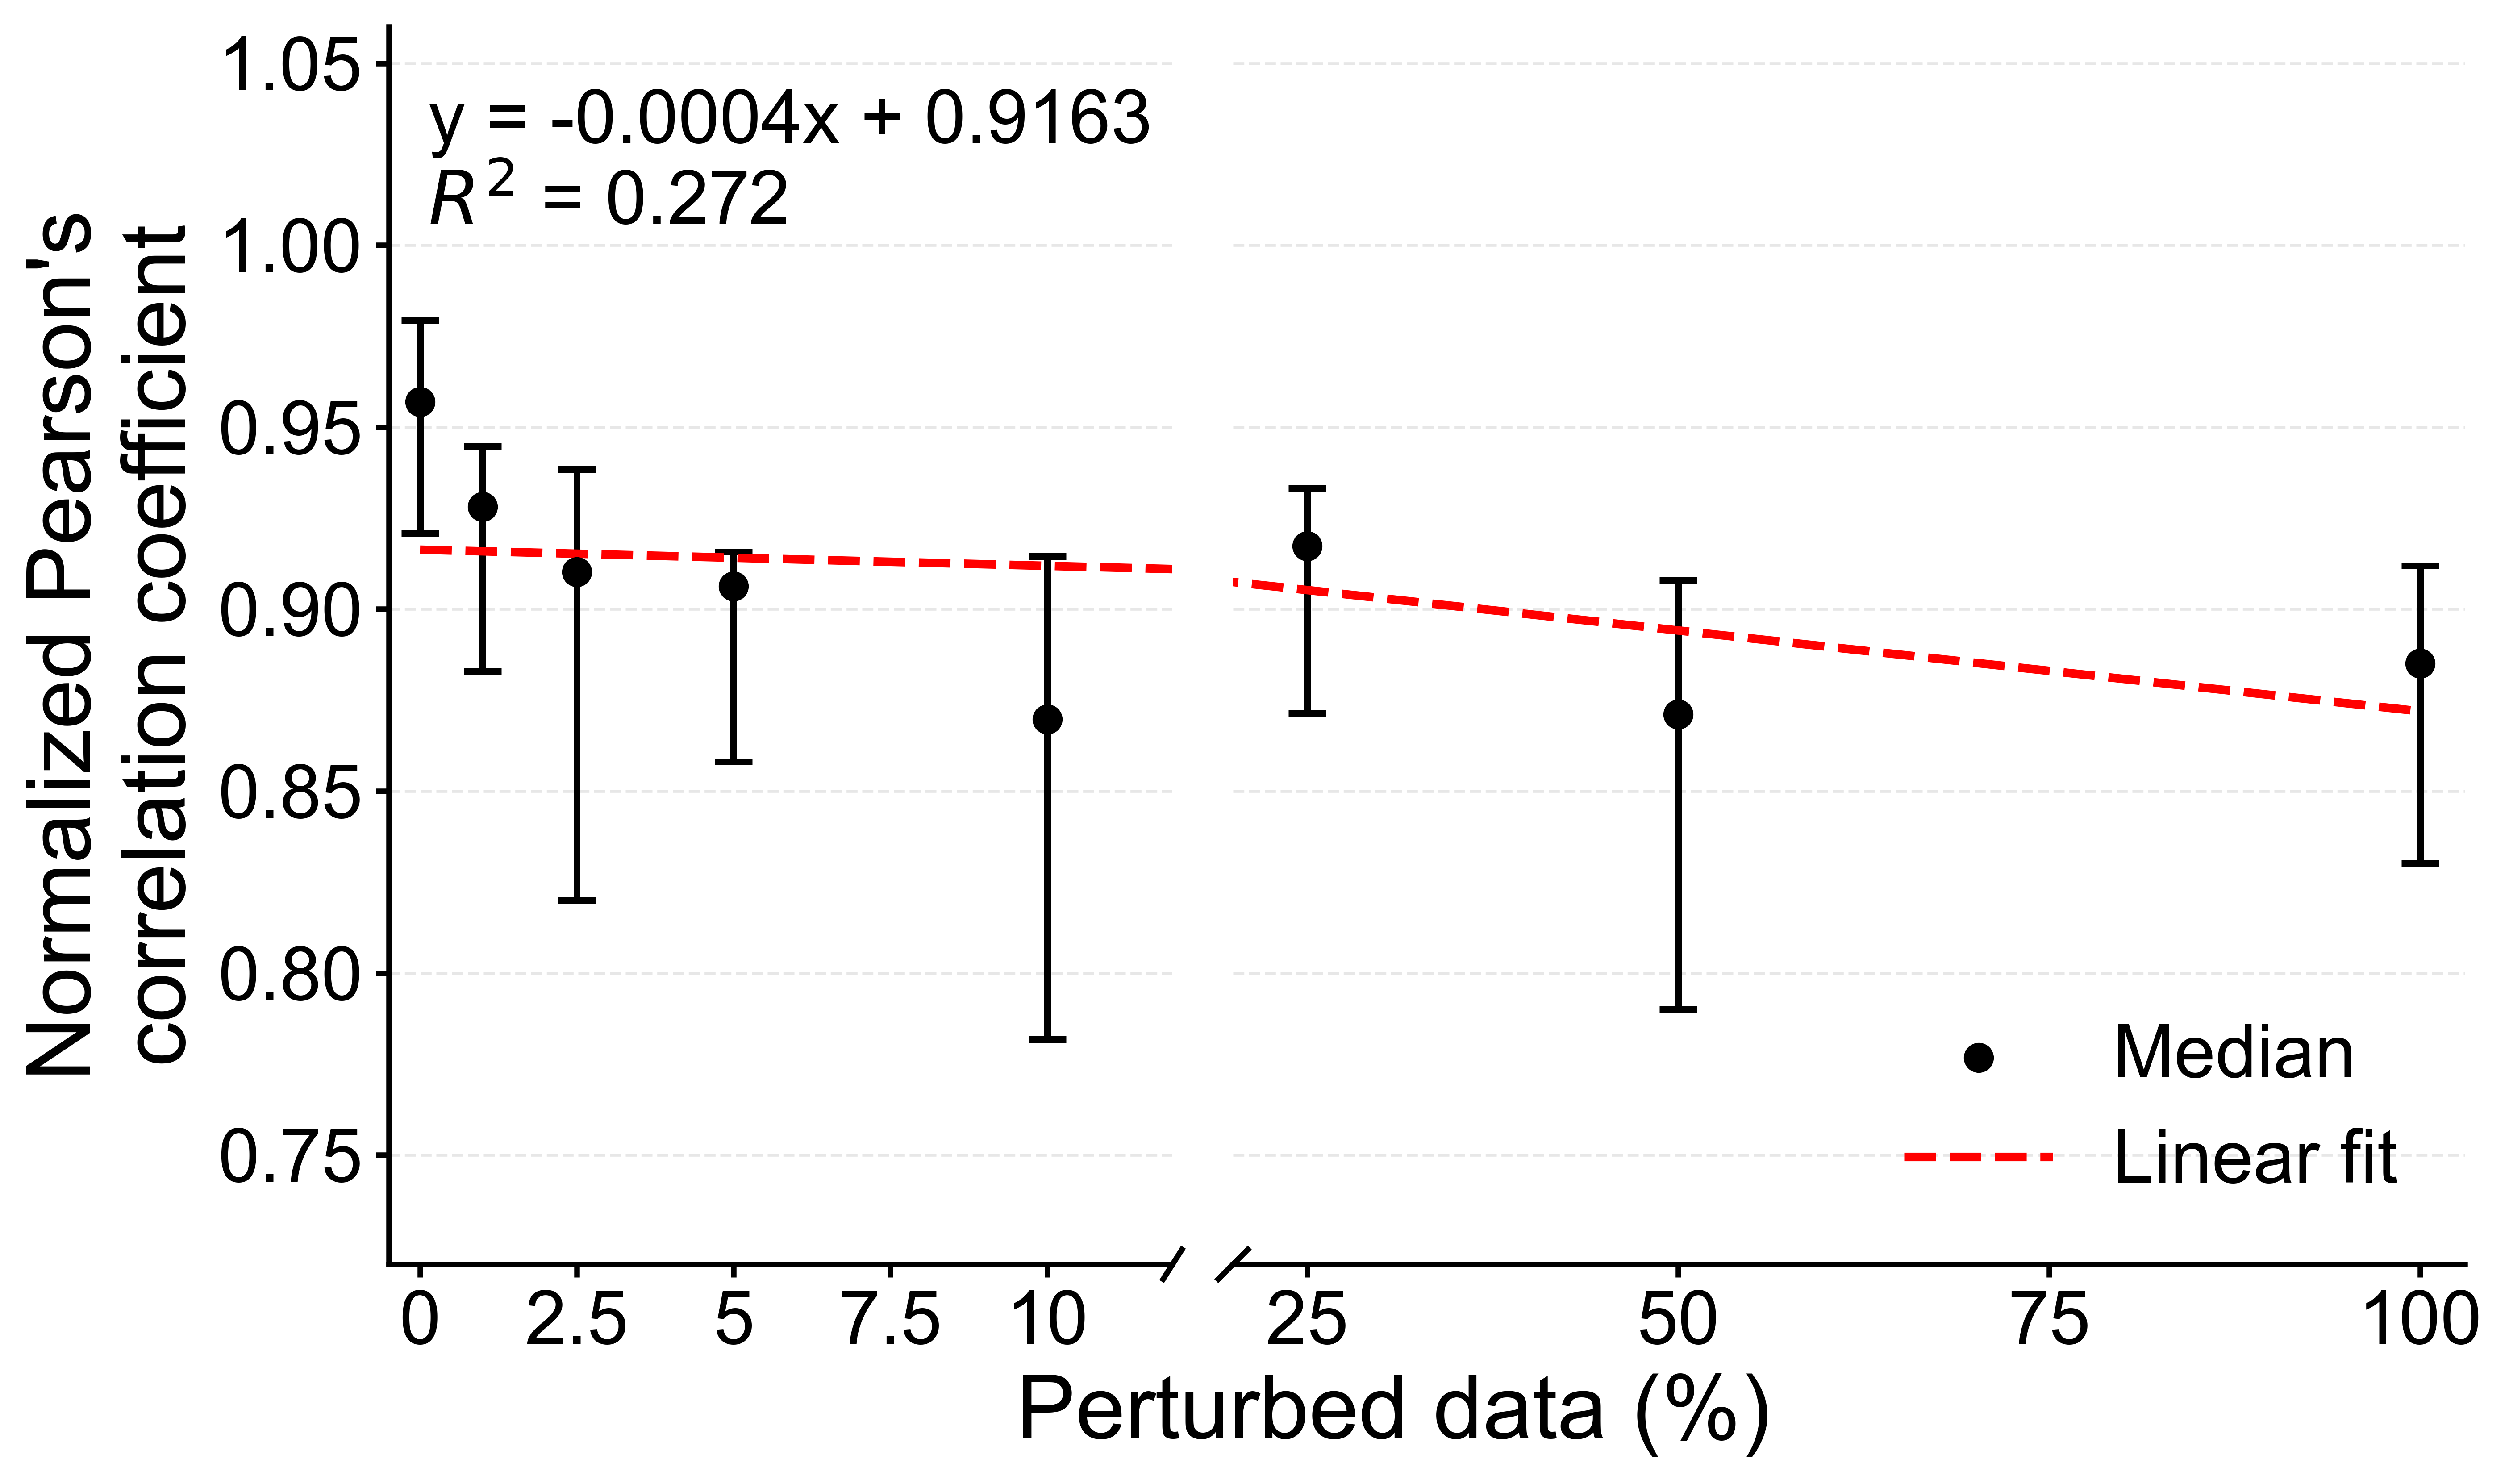

In [31]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Pearson_CNN2_MLP_GNN.txt",
    "Pearson_CNN2_MLP_GNN_001.txt",
    "Pearson_CNN2_MLP_GNN_0025.txt",
    "Pearson_CNN2_MLP_GNN_005.txt",
    "Pearson_CNN2_MLP_GNN_010.txt",
    "Pearson_CNN2_MLP_GNN_025.txt",
    "Pearson_CNN2_MLP_GNN_050.txt",
    "Pearson_CNN2_MLP_GNN_100.txt"
]

# Actual perturbation percentages
perturbation = np.array([0, 1, 2.5, 5, 10, 25, 50, 100])

# ============================================================
# Load data
# ============================================================

groups = []

for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# ============================================================
# Global normalization
# ============================================================

all_values = np.concatenate(groups)

vmin = all_values.min()
vmax = all_values.max()

groups_norm = [
    (g - vmin) / (vmax - vmin)
    for g in groups
]

# ============================================================
# Calculate median, 25th percentile, and 75th percentile
# ============================================================

medians = np.array([
    np.median(g)
    for g in groups_norm
])

q25 = np.array([
    np.percentile(g, 25)
    for g in groups_norm
])

q75 = np.array([
    np.percentile(g, 75)
    for g in groups_norm
])

# Error-bar lengths
lower_error = medians - q25
upper_error = q75 - medians

yerr = np.vstack([
    lower_error,
    upper_error
])

# ============================================================
# Linear regression of median values
# ============================================================

slope, intercept = np.polyfit(
    perturbation,
    medians,
    1
)

# Generate many x-values so regression line is smooth
x_fit = np.linspace(
    perturbation.min(),
    perturbation.max(),
    500
)

y_fit = slope * x_fit + intercept

# Predicted values at actual perturbation percentages
predicted = slope * perturbation + intercept

# R²
ss_res = np.sum(
    (medians - predicted) ** 2
)

ss_tot = np.sum(
    (medians - np.mean(medians)) ** 2
)

r_squared = 1 - ss_res / ss_tot

print("Median values:")

for x, median, lower, upper in zip(
    perturbation,
    medians,
    q25,
    q75
):
    print(
        f"{x:5.1f}%: "
        f"median = {median:.4f}, "
        f"25th = {lower:.4f}, "
        f"75th = {upper:.4f}"
    )

print()
print(f"Slope     = {slope:.6f}")
print(f"Intercept = {intercept:.6f}")
print(f"R²        = {r_squared:.4f}")


# ============================================================
# Plot settings
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

# Two x-axis regions:
# left = 0–12%
# right = 20–103%
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 6),
    dpi=600,
    gridspec_kw={
        "width_ratios": [1.4, 2.2],
        "wspace": 0.06
    }
)

# ============================================================
# Function for plotting the same data on both axes
# ============================================================

def plot_data(ax):

    # Median points
    ax.scatter(
        perturbation,
        medians,
        color="black",
        s=50,
        zorder=3,
        label="Median"
    )

    # 25th–75th percentile bars
    ax.errorbar(
        perturbation,
        medians,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1.8,
        capsize=5,
        capthick=1.8,
        zorder=2
    )

    # Linear regression line
    ax.plot(
        x_fit,
        y_fit,
        color="red",
        linewidth=2.3,
        linestyle="--",
        label="Linear fit"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)


# Plot on both axes
plot_data(ax1)
plot_data(ax2)

# ============================================================
# Define the two continuous x-axis regions
# ============================================================

ax1.set_xlim(-0.5, 12)
ax2.set_xlim(20, 103)

# Left region: low perturbation levels
ax1.set_xticks([
    0,
    2.5,
    5,
    7.5,
    10
])

ax1.set_xticklabels([
    "0",
    "2.5",
    "5",
    "7.5",
    "10"
])

# Right region
ax2.set_xticks([
    25,
    50,
    75,
    100
])

ax2.set_xticklabels([
    "25",
    "50",
    "75",
    "100"
])

# ============================================================
# Y-axis
# ============================================================

ax1.set_ylim(0.72, 1.06)

ax1.set_ylabel(
    "Normalized Pearson's\ncorrelation coefficient",
    fontsize=24
)

# Common X-axis label
fig.supxlabel(
    "Perturbed data (%)",
    fontsize=24,
    y=-0.01
)

# ============================================================
# Remove internal spines
# ============================================================

ax1.spines["right"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# ============================================================
# Add broken-axis diagonal marks
# ============================================================

d = 0.012

kwargs = dict(
    transform=ax1.transAxes,
    color="black",
    clip_on=False,
    linewidth=1.5
)

ax1.plot(
    (1 - d, 1 + d),
    (-d, +d),
    **kwargs
)

kwargs.update(
    transform=ax2.transAxes
)

ax2.plot(
    (-d, +d),
    (-d, +d),
    **kwargs
)

# ============================================================
# Regression equation and R²
# ============================================================

equation_text = (
    f"y = {slope:.4f}x + {intercept:.4f}\n"
    f"$R^2$ = {r_squared:.3f}"
)

ax1.text(
    0.05,
    0.95,
    equation_text,
    transform=ax1.transAxes,
    fontsize=20,
    verticalalignment="top",
    horizontalalignment="left"
)

# ============================================================
# Legend
# ============================================================

ax2.legend(
    loc="lower right",
    frameon=False,
    fontsize=20
)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    "Pearson_median_linear_fit_broken_axis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

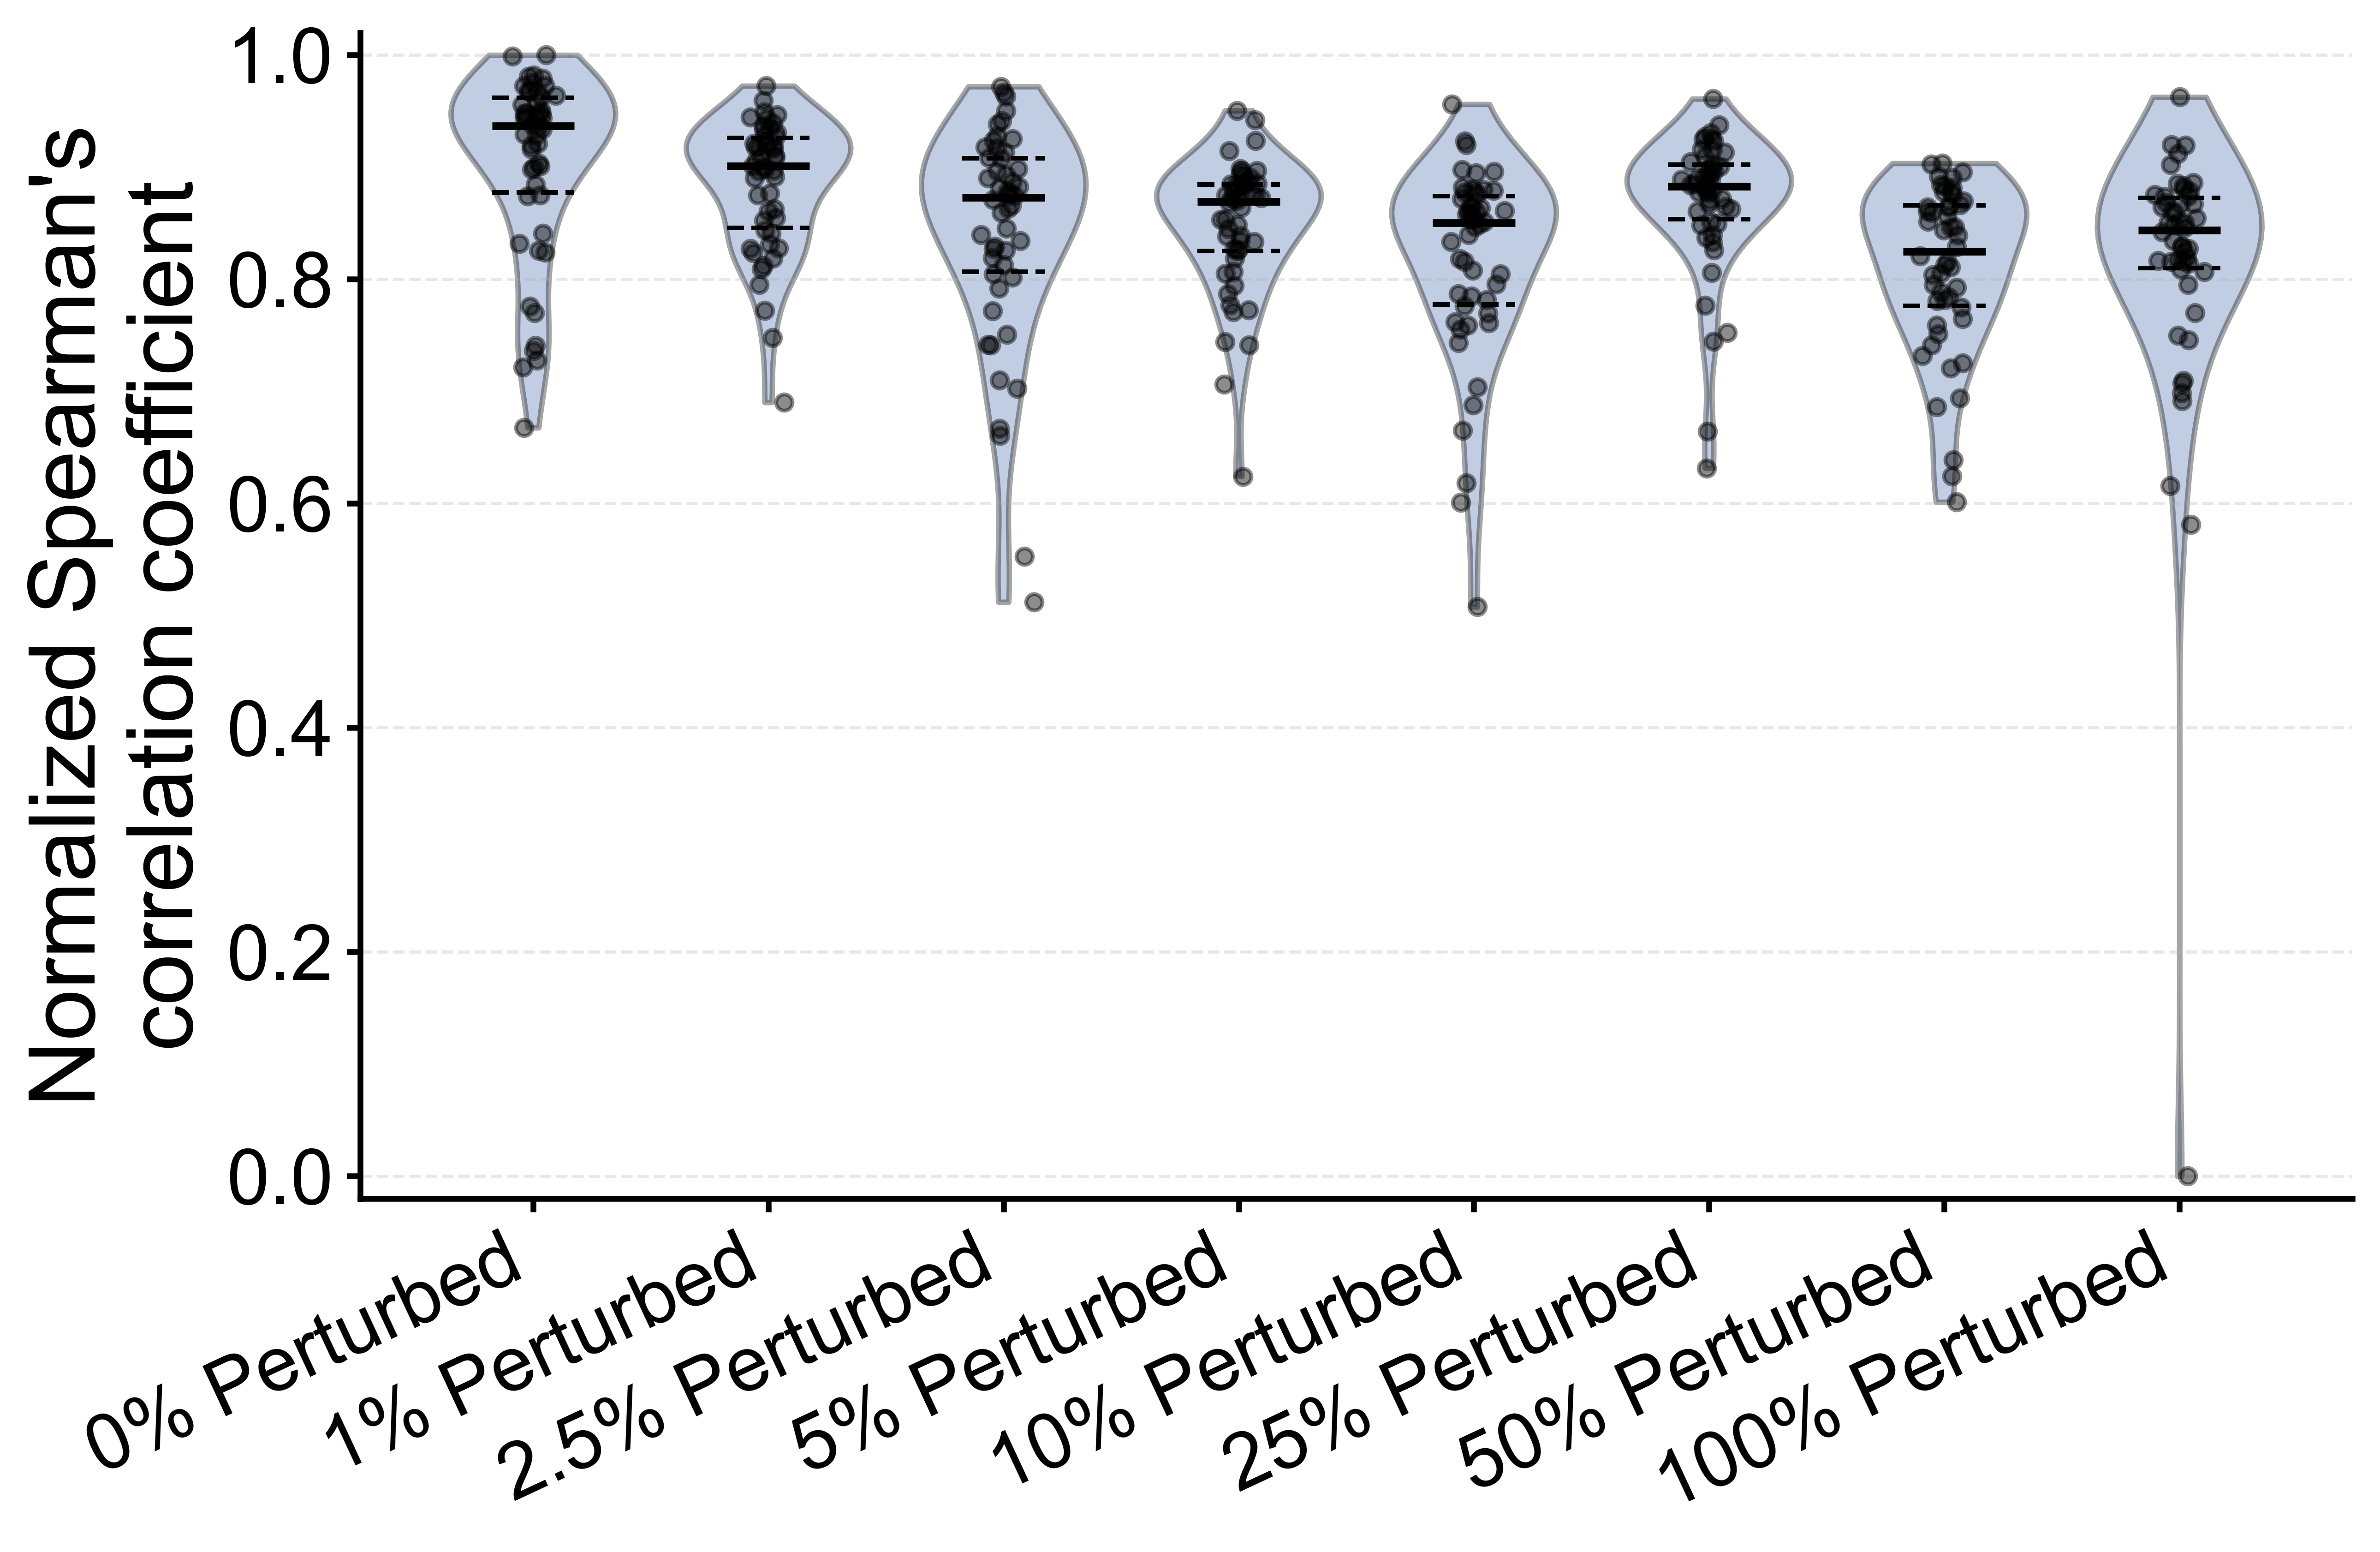

In [32]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Spearman_CNN2_MLP_GNN.txt",
    "Spearman_CNN2_MLP_GNN_001.txt",
    "Spearman_CNN2_MLP_GNN_0025.txt",
    "Spearman_CNN2_MLP_GNN_005.txt",
    "Spearman_CNN2_MLP_GNN_010.txt",
    "Spearman_CNN2_MLP_GNN_025.txt",
    "Spearman_CNN2_MLP_GNN_050.txt",
    "Spearman_CNN2_MLP_GNN_100.txt"
]

labels = [
    "0% Perturbed",
    "1% Perturbed",
    "2.5% Perturbed",
    "5% Perturbed",
    "10% Perturbed",
    "25% Perturbed",
    "50% Perturbed",
    "100% Perturbed"
]

groups = []
for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# Normalize using global min and max across all five groups
all_values = np.concatenate(groups)
vmin = all_values.min()
vmax = all_values.max()

groups_norm = [(g - vmin) / (vmax - vmin) for g in groups]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

fig, ax = plt.subplots(figsize=(9, 6), dpi=600)

parts = ax.violinplot(
    groups_norm,
    positions=np.arange(1, len(groups_norm) + 1),
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False,
    quantiles=[[0.25, 0.75]] * len(groups_norm)
)

for body in parts["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_edgecolor("black")
    body.set_alpha(0.35)
    body.set_linewidth(1.4)

parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

parts["cquantiles"].set_color("black")
parts["cquantiles"].set_linestyle("--")
parts["cquantiles"].set_linewidth(1.2)

rng = np.random.default_rng(42)

for i, data in enumerate(groups_norm, start=1):
    x = rng.normal(i, 0.045, len(data))
    ax.scatter(
        x,
        data,
        s=18,
        color="black",
        alpha=0.45,
        zorder=3
    )

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=25, ha="right")

ax.set_ylabel("Normalized Spearman's\ncorrelation coefficient", fontsize=24)
ax.set_ylim(-0.02, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("Spearman_violin_plot.png", dpi=600, bbox_inches="tight")
plt.show()

Median values:
  0.0%: median = 0.9367, 25th = 0.8774, 75th = 0.9617
  1.0%: median = 0.9007, 25th = 0.8457, 75th = 0.9259
  2.5%: median = 0.8729, 25th = 0.8067, 75th = 0.9080
  5.0%: median = 0.8692, 25th = 0.8254, 75th = 0.8847
 10.0%: median = 0.8502, 25th = 0.7775, 75th = 0.8744
 25.0%: median = 0.8827, 25th = 0.8536, 75th = 0.9021
 50.0%: median = 0.8249, 25th = 0.7764, 75th = 0.8661
100.0%: median = 0.8438, 25th = 0.8102, 75th = 0.8726

Slope     = -0.000610
Intercept = 0.887411
R²        = 0.3703


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_30493/1842182901.py:338: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


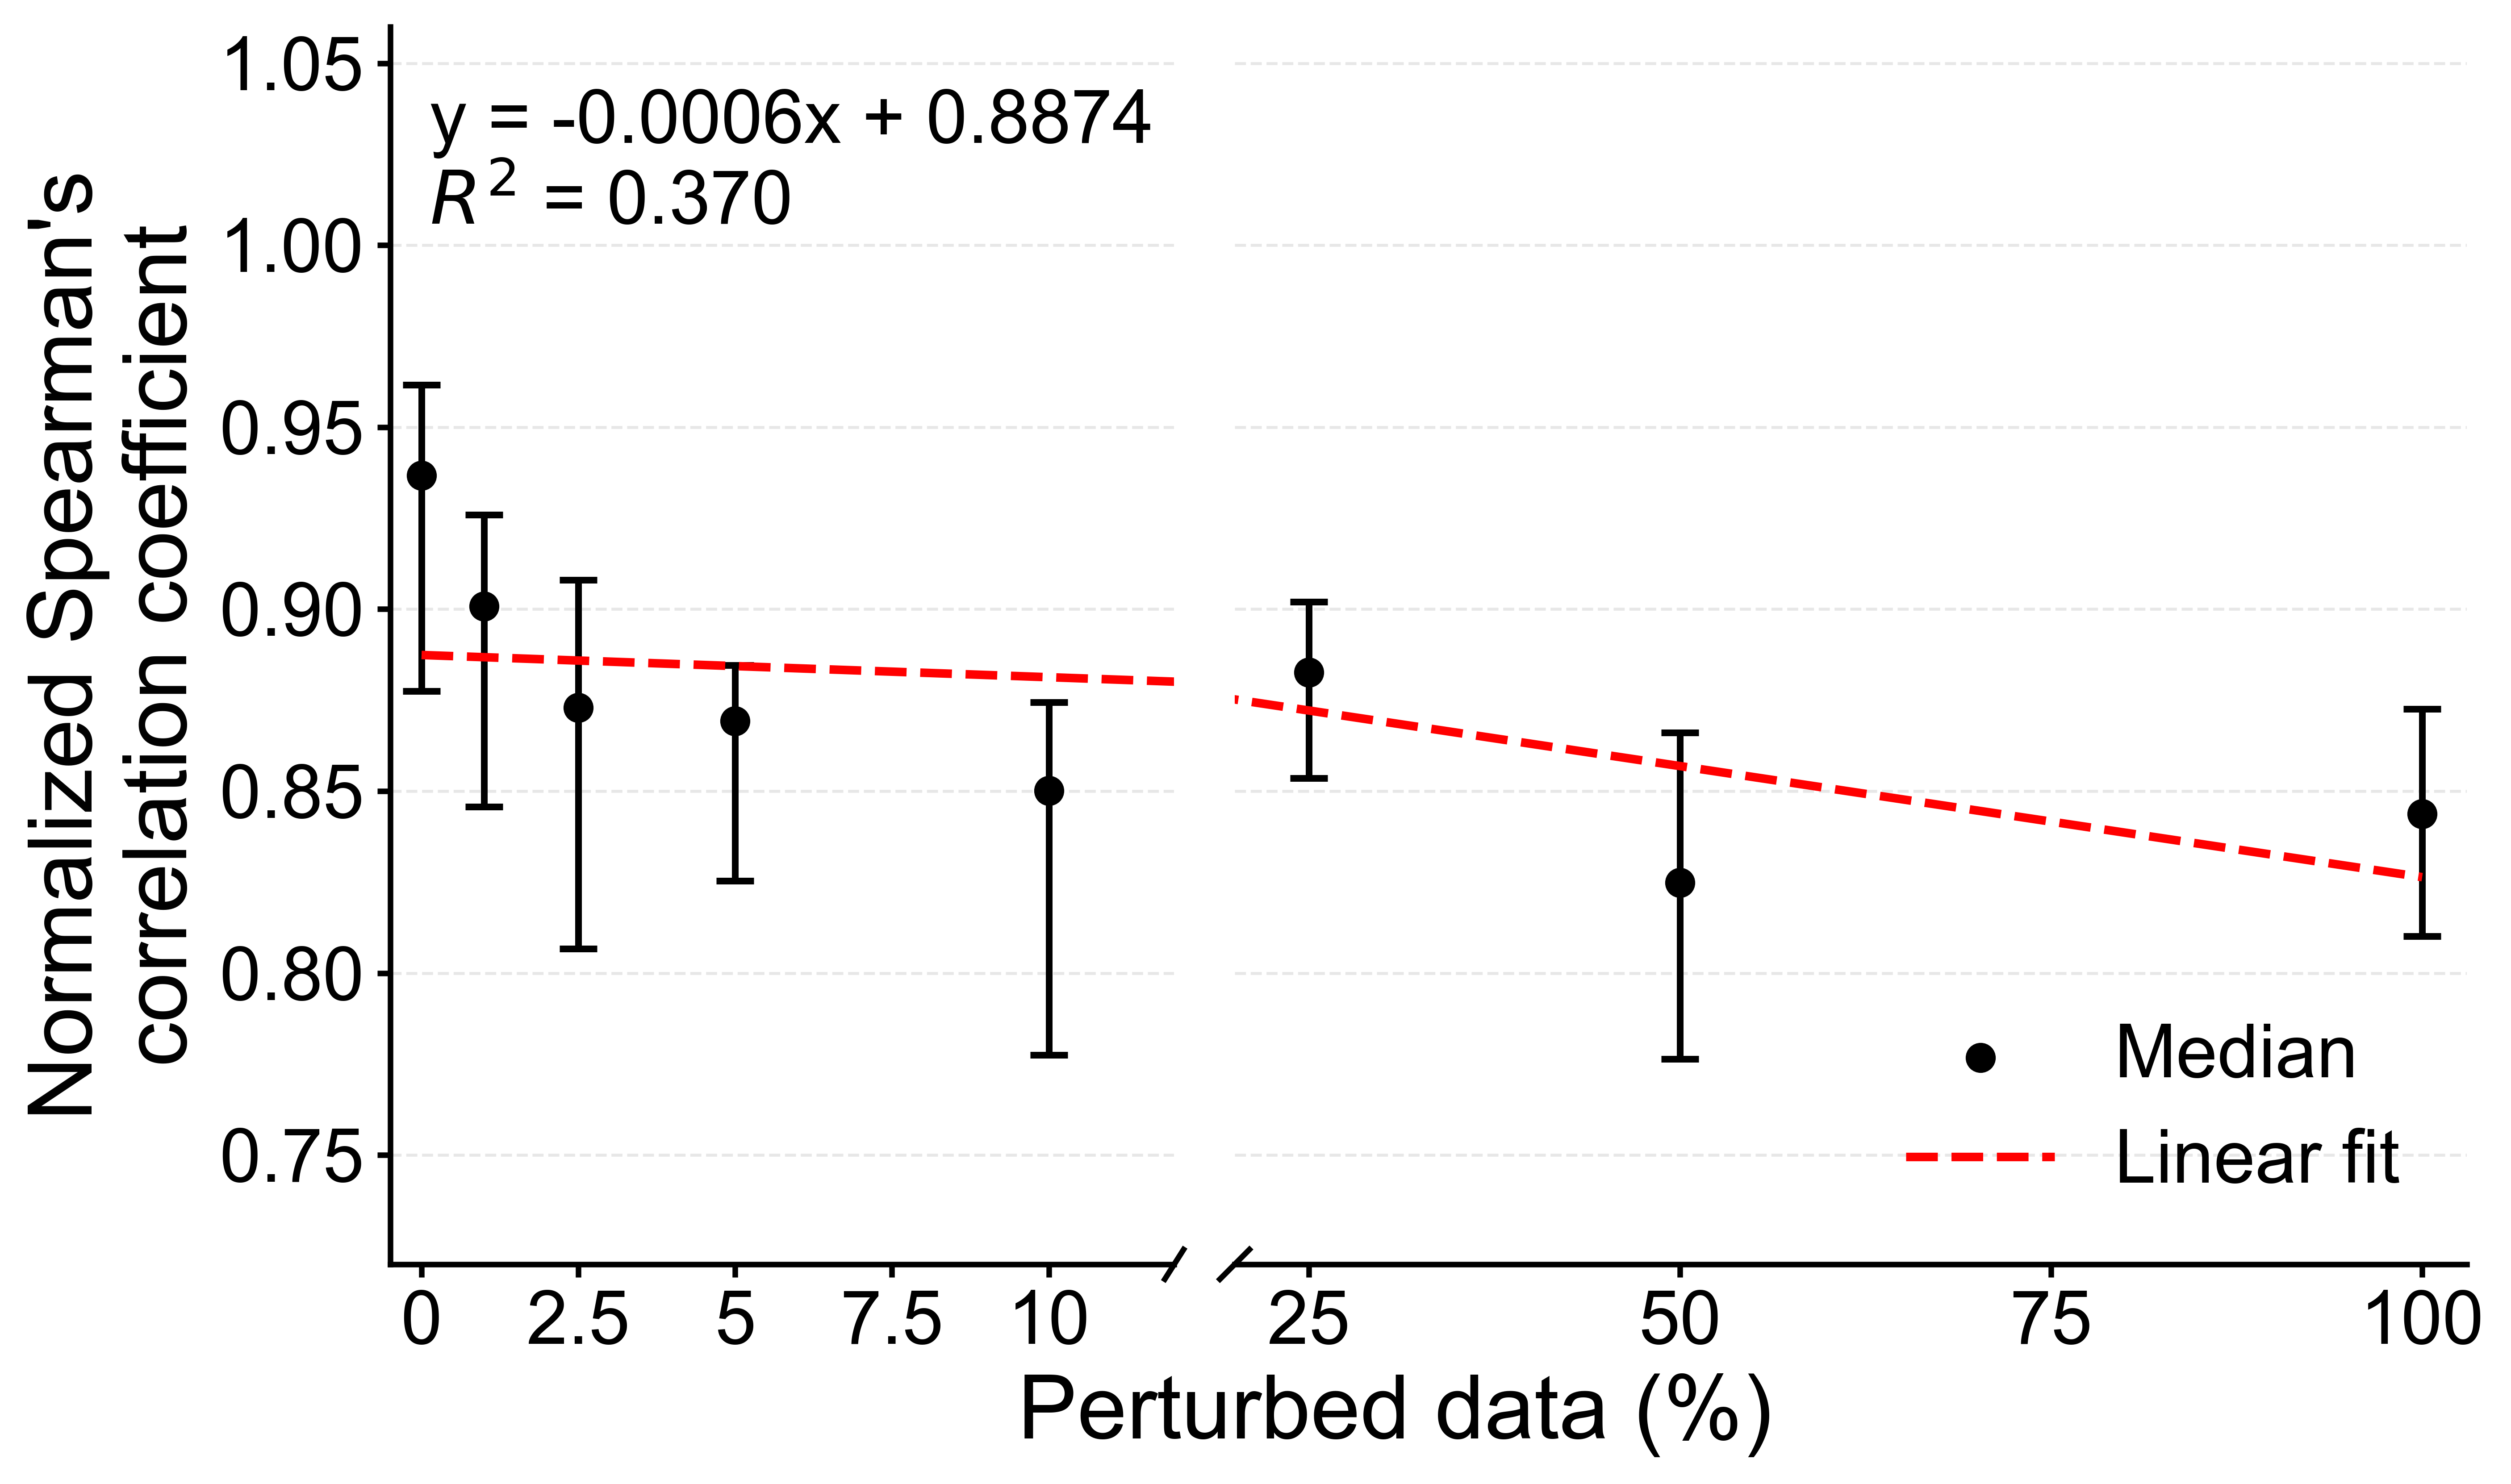

In [33]:
import numpy as np
import matplotlib.pyplot as plt

files = [
    "Spearman_CNN2_MLP_GNN.txt",
    "Spearman_CNN2_MLP_GNN_001.txt",
    "Spearman_CNN2_MLP_GNN_0025.txt",
    "Spearman_CNN2_MLP_GNN_005.txt",
    "Spearman_CNN2_MLP_GNN_010.txt",
    "Spearman_CNN2_MLP_GNN_025.txt",
    "Spearman_CNN2_MLP_GNN_050.txt",
    "Spearman_CNN2_MLP_GNN_100.txt"
]

# Actual perturbation percentages
perturbation = np.array([0, 1, 2.5, 5, 10, 25, 50, 100])

# ============================================================
# Load data
# ============================================================

groups = []

for file in files:
    data = np.loadtxt(file)
    data = data[np.isfinite(data)]   # remove NaN and inf
    groups.append(data)

# ============================================================
# Global normalization
# ============================================================

all_values = np.concatenate(groups)

vmin = all_values.min()
vmax = all_values.max()

groups_norm = [
    (g - vmin) / (vmax - vmin)
    for g in groups
]

# ============================================================
# Calculate median, 25th percentile, and 75th percentile
# ============================================================

medians = np.array([
    np.median(g)
    for g in groups_norm
])

q25 = np.array([
    np.percentile(g, 25)
    for g in groups_norm
])

q75 = np.array([
    np.percentile(g, 75)
    for g in groups_norm
])

# Error-bar lengths
lower_error = medians - q25
upper_error = q75 - medians

yerr = np.vstack([
    lower_error,
    upper_error
])

# ============================================================
# Linear regression of median values
# ============================================================

slope, intercept = np.polyfit(
    perturbation,
    medians,
    1
)

# Generate many x-values so regression line is smooth
x_fit = np.linspace(
    perturbation.min(),
    perturbation.max(),
    500
)

y_fit = slope * x_fit + intercept

# Predicted values at actual perturbation percentages
predicted = slope * perturbation + intercept

# R²
ss_res = np.sum(
    (medians - predicted) ** 2
)

ss_tot = np.sum(
    (medians - np.mean(medians)) ** 2
)

r_squared = 1 - ss_res / ss_tot

print("Median values:")

for x, median, lower, upper in zip(
    perturbation,
    medians,
    q25,
    q75
):
    print(
        f"{x:5.1f}%: "
        f"median = {median:.4f}, "
        f"25th = {lower:.4f}, "
        f"75th = {upper:.4f}"
    )

print()
print(f"Slope     = {slope:.6f}")
print(f"Intercept = {intercept:.6f}")
print(f"R²        = {r_squared:.4f}")


# ============================================================
# Plot settings
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 20,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
})

# Two x-axis regions:
# left = 0–12%
# right = 20–103%
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 6),
    dpi=600,
    gridspec_kw={
        "width_ratios": [1.4, 2.2],
        "wspace": 0.06
    }
)

# ============================================================
# Function for plotting the same data on both axes
# ============================================================

def plot_data(ax):

    # Median points
    ax.scatter(
        perturbation,
        medians,
        color="black",
        s=50,
        zorder=3,
        label="Median"
    )

    # 25th–75th percentile bars
    ax.errorbar(
        perturbation,
        medians,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1.8,
        capsize=5,
        capthick=1.8,
        zorder=2
    )

    # Linear regression line
    ax.plot(
        x_fit,
        y_fit,
        color="red",
        linewidth=2.3,
        linestyle="--",
        label="Linear fit"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)


# Plot on both axes
plot_data(ax1)
plot_data(ax2)

# ============================================================
# Define the two continuous x-axis regions
# ============================================================

ax1.set_xlim(-0.5, 12)
ax2.set_xlim(20, 103)

# Left region: low perturbation levels
ax1.set_xticks([
    0,
    2.5,
    5,
    7.5,
    10
])

ax1.set_xticklabels([
    "0",
    "2.5",
    "5",
    "7.5",
    "10"
])

# Right region
ax2.set_xticks([
    25,
    50,
    75,
    100
])

ax2.set_xticklabels([
    "25",
    "50",
    "75",
    "100"
])

# ============================================================
# Y-axis
# ============================================================

ax1.set_ylim(0.72, 1.06)

ax1.set_ylabel(
    "Normalized Spearman's\ncorrelation coefficient",
    fontsize=24
)

# Common X-axis label
fig.supxlabel(
    "Perturbed data (%)",
    fontsize=24,
    y=-0.01
)

# ============================================================
# Remove internal spines
# ============================================================

ax1.spines["right"].set_visible(False)

ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)

# ============================================================
# Add broken-axis diagonal marks
# ============================================================

d = 0.012

kwargs = dict(
    transform=ax1.transAxes,
    color="black",
    clip_on=False,
    linewidth=1.5
)

ax1.plot(
    (1 - d, 1 + d),
    (-d, +d),
    **kwargs
)

kwargs.update(
    transform=ax2.transAxes
)

ax2.plot(
    (-d, +d),
    (-d, +d),
    **kwargs
)

# ============================================================
# Regression equation and R²
# ============================================================

equation_text = (
    f"y = {slope:.4f}x + {intercept:.4f}\n"
    f"$R^2$ = {r_squared:.3f}"
)

ax1.text(
    0.05,
    0.95,
    equation_text,
    transform=ax1.transAxes,
    fontsize=20,
    verticalalignment="top",
    horizontalalignment="left"
)

# ============================================================
# Legend
# ============================================================

ax2.legend(
    loc="lower right",
    frameon=False,
    fontsize=20
)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    "Spearman_median_linear_fit_broken_axis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()